# Newton Interpolation


## Importing Modules


In [39]:
import numpy as np
import matplotlib.pyplot as plt

## Initializing Variables


In [40]:
x = [-1 , -0.5 , 0 , 0.5 , 1]
y = [0.038, 0.138, 1.000, 0.138, 0.038]

## Newton Interpolation Function


In [41]:
def divided_diff(x, y):
    '''
    Function to calculate the divided differences table
    '''
    
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y
    
    for j in range(1,n):
        for i in range(n-j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j]-x[i])
            
    return coef

def newton_poly(coef, x_data, x):
    '''
    Evaluate the Newton polynomial at x
    '''
    
    n = len(x_data) - 1
    p = coef[n]
    for k in range(1,n+1):
        p = coef[n-k] + (x - x_data[n-k]) * p
    return p
    

## Calculation of Newton Interpolation


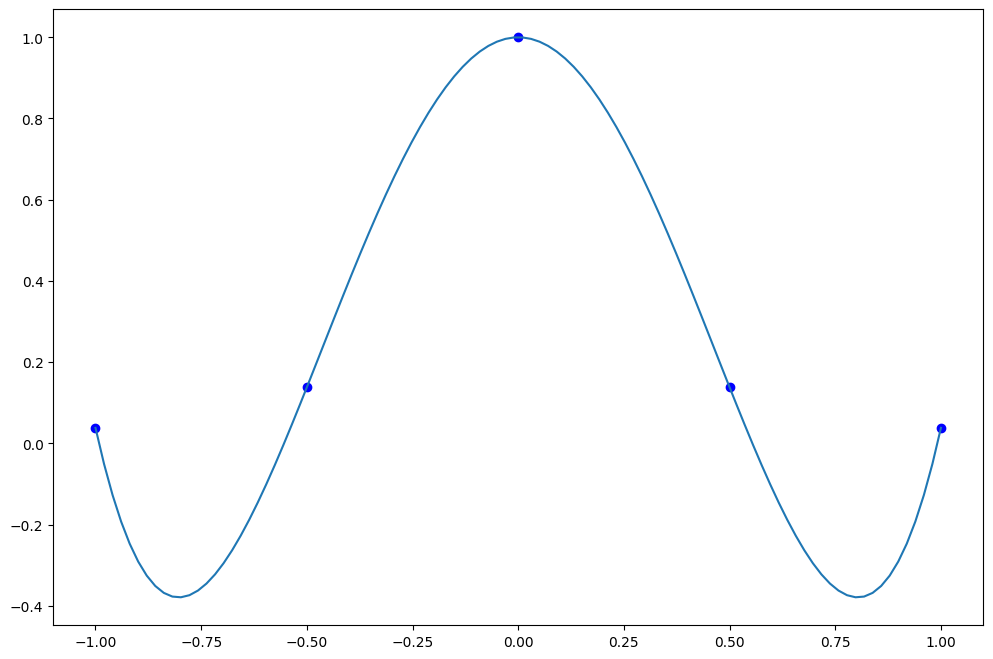

In [42]:
# Divided Difference Coefficient
a_s = divided_diff(x, y)[0, :]

# Evaluate on New Data Points
x_new = np.linspace(-1, 1, 100)
y_new = [newton_poly(a_s, x, xi) for xi in x_new]

# Make Graph
plt.figure(figsize = (12, 8))
plt.plot(x, y, 'bo')
plt.plot(x_new, y_new)

As we can see, this is the data we got from Newton interpolation. if you're wondering why we use

```py
x_new = np.linspace(-1, 1, 100)
```

which is different from the code in Deck Material, that's because the assignment explicitly told us to use that `x_new` data, to prevent the plot data outside the domain (or range).

But watch as we changed the data a bit.


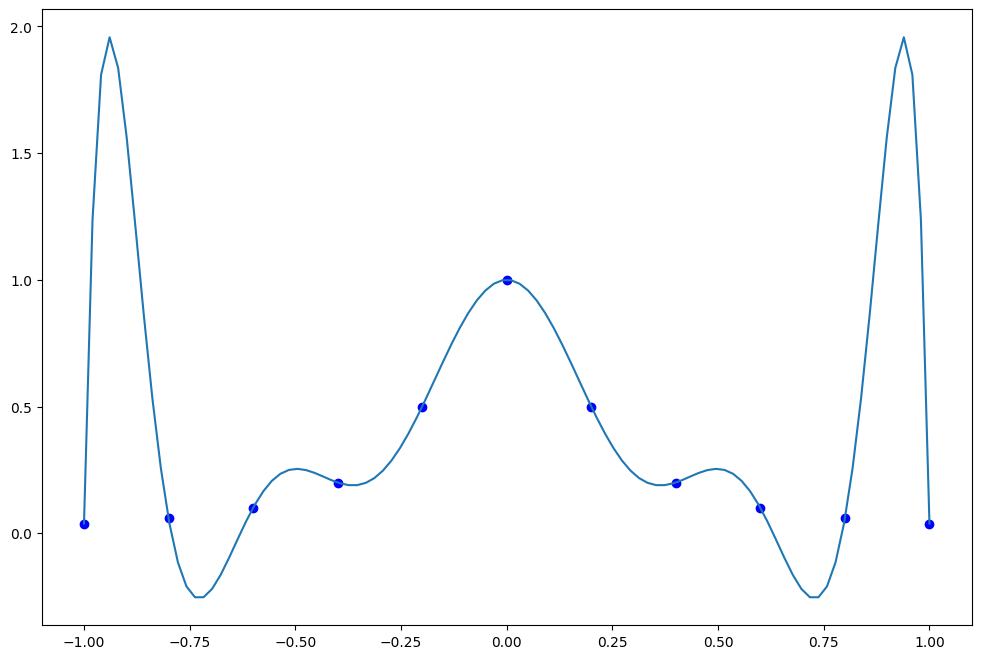

In [43]:
# Data changed
neo_x = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1]
neo_y = [0.038, 0.058, 0.100, 0.200, 0.500, 1.000, 0.500, 0.200, 0.100, 0.058, 0.038]

# Divided Difference Coefficient
a_s = divided_diff(neo_x, neo_y)[0, :]

# Evaluate on New Data Points
neo_x_new = np.linspace(-1, 1, 100)
neo_y_new = [newton_poly(a_s, neo_x, xi) for xi in neo_x_new]

# Make Graph
plt.figure(figsize = (12, 8))
plt.plot(neo_x, neo_y, 'bo')
plt.plot(neo_x_new, neo_y_new)

A bit confusing? Here's both graph overlapped.


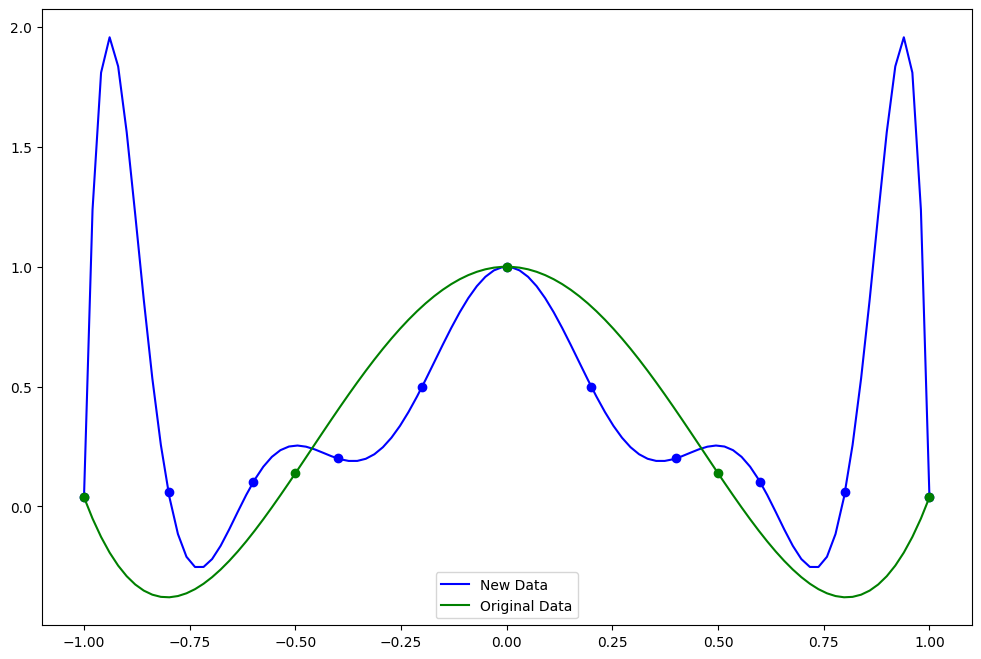

In [44]:
plt.figure(figsize = (12, 8))
plt.plot(neo_x, neo_y, 'bo')
plt.plot(neo_x_new, neo_y_new, 'b', label='New Data')

plt.plot(x, y, 'go')
plt.plot(x_new, y_new, 'g', label='Original Data')
plt.legend()

## My Hypothesis


1. After adding more data point, we saw the new graph (blue line), ~~a bit~~ actually **severely out of place**. Sure we met the point of First, Last and Median Data, but the graphic shows anomaly of the data. (Runge's Phenomenon)

2. This happens because Newton interpolation relies on divided difference, which can cause issues for the data to "overshoot", Well outside normal ranges.

3. My hypothesis for stability: We can use something like Cubic Interpolation, because it uses only third degree polynomial to do its computation. (We can test this, wait, we do!)


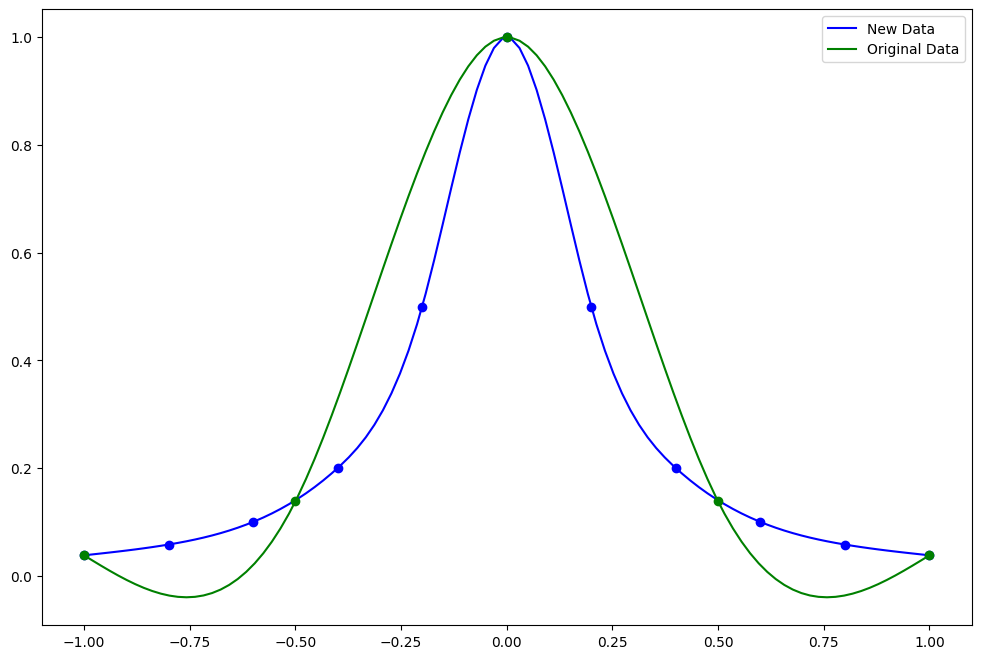

In [45]:
from scipy.interpolate import CubicSpline

f = CubicSpline(x, y, bc_type='natural')
x_new = np.linspace(-1, 1, 100)
y_new = f(x_new)

f = CubicSpline(neo_x, neo_y, bc_type='natural')
neo_x_new = np.linspace(-1, 1, 100)
neo_y_new = f(neo_x_new)

plt.figure(figsize = (12, 8))
plt.plot(neo_x, neo_y, 'bo')
plt.plot(neo_x_new, neo_y_new, 'b', label='New Data')
plt.plot(x, y, 'go')
plt.plot(x_new, y_new, 'g', label='Original Data')
plt.legend()